In [217]:
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
from scipy.integrate import solve_ivp
from scipy import signal
import copy
import os
import control as ct

# Local Packages
from control_utils.politopic_representation import *
from control_utils import levants

rng = np.random.default_rng()

In [218]:
# simulation time
time = 10
mi = 1.0 # damping coeficient
coupling_factor = 1.0
eta = .9
eps = 1e-9
x0 = np.array([
    3, -2, 0, 0, -2, -2,
    0, 0, 0, 0, 0, 0
])
x0_levants = np.zeros(15)

x0 = np.concat([x0, x0_levants], axis=0)

# normal cases
z_interval = [
    [0, 25],
    [0, 25],
    [0, 25],
]
zeta_interval = [
    
]

# hyperplanes
a = np.array([
    [1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, -1],
])

b = np.array([5, 5, 10, 10, 5, 5, 10, 10, 5, 5, 10, 10]).reshape(12, 1) + 1
bR = b - 1

In [219]:
n_z = len(z_interval)
n_zeta = len(zeta_interval)

interval_size = 2 # Just to make this information explict

j_perms, _ = permn(np.arange(interval_size), n_z)
k_perms, _ = permn(np.arange(interval_size), n_z)
l_perms, _ = permn(np.arange(interval_size), n_zeta)

In [220]:
### This functions must be changed for different systems
# Politopic representation
def A_ijl(z: list[np.ndarray], zeta: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0],
    ])

def C_ijl(z: list[np.ndarray], zeta: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
    ])

theta_x1 = lambda x1: 3 + 2*math.sin(x1)

# alpha = [x1, x4_hat]
z_alpha = lambda alpha: np.array([
    [alpha[0]**2],
    [alpha[1]**2],
    [alpha[2]**2]
])

In [221]:
A_cell = []
C_cell = []

for j_p in j_perms:
    for l_p in l_perms or [None]:
        
        to_concat = None
        if l_p != None:
            to_concat = [j_p, l_p]
        else:
            to_concat = [j_p]

        jl_perm = np.concat(to_concat)
        A_ind = bin_perm_to_dec(jl_perm)
        C_ind = A_ind

        z = []
        for j in range(n_z):
            z.append(z_interval[j][jl_perm[j]])
        
        zeta = []
        for j in range(n_zeta):
            zeta.append(zeta_interval[j][jl_perm[n_z + j]])
        A_cell.append(A_ijl(z, zeta))
        C_cell.append(C_ijl(z, zeta))

C:\Users\luiza\AppData\Local\Temp\ipykernel_120396\338974435.py:5: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  for l_p in l_perms or [None]:


In [222]:
non_count = 0
for i in range(len(A_cell)):
    if (np.linalg.matrix_rank(ct.obsv(A_cell[i], C_cell[i])) == A_cell[i].shape[0]) == np.False_:
        non_count += 1
print(f"found {non_count} non observable pairs out of {len(A_cell)}")

found 0 non observable pairs out of 8


In [223]:
j_perms_plus = perm_plus(j_perms)
k_perms_plus = perm_plus(k_perms)

In [224]:
def phi_z(F: np.ndarray, z: np.ndarray, b: np.ndarray): # TODO: move to a local utils under project UIO or to the LMIS definition
    '''
        ### The parameters are given from the expressions and are used to generate Lmis for Theorem 1 of Coutinho et al.
        R = { x \in RR^n : F@x <= b} \\
        phi(z) = min{ b.T@w: F.T@w = z, w \in RR^f >= 0 }
    '''

    w = cp.Variable((b.shape[0], 1))
    constrains = []

    constrains += [ w >= 0]
    
    constrains += [ F.T@w == z ]

    prob = cp.Problem(cp.Minimize(b.T@w), constraints=constrains)
    result = prob.solve(solver=cp.MOSEK, verbose=False)

    return result

<>:2: SyntaxWarning: invalid escape sequence '\i'
<>:2: SyntaxWarning: invalid escape sequence '\i'
C:\Users\luiza\AppData\Local\Temp\ipykernel_120396\4255820786.py:2: SyntaxWarning: invalid escape sequence '\i'
  '''


In [225]:
### LMIS

nx = A_cell[0].shape[0]
ny = C_cell[0].shape[0]

P = cp.Variable((nx, nx), symmetric=True)

L_till_cell = []
for perm in k_perms:
    L_till = cp.Variable((nx, ny))
    L_till_cell.append(L_till)

constrains = []
constrains += [P >> eps]

# fixing upsilon
for l in l_perms or [None]:

    for m_index in j_perms_plus:
        for n_index in k_perms_plus:

            m_perms = multi_index_permutation(copy.deepcopy(m_index))
            n_perms = multi_index_permutation(copy.deepcopy(n_index))

            Upsilon_mnk_sum = 0
            for m_perm in m_perms:
                for n_perm in n_perms:

                    to_concat = None
                    if l_p != None:
                        to_concat = [j_p, l_p]
                    else:
                        to_concat = [j_p]

                    jl_perm = np.concat(to_concat)
                    
                    A_ind = bin_perm_to_dec(copy.deepcopy(jl_perm))
                    L_ind = bin_perm_to_dec(copy.deepcopy(n_perm))
                    C_ind = A_ind

                    M = P@A_cell[A_ind] - L_till_cell[L_ind]@C_cell[C_ind] + eta*P
                    Upsilon_mnk_sum += M + M.T
        
            constrains += [Upsilon_mnk_sum << -eps]

for j in range(a.T.shape[0]):
    # a.T@x <= b
    aj = np.expand_dims(a.T[j], axis=1)
    phi = phi_z(a.T, aj, bR)
    sj = 1/(b[j] - phi) * aj

    M = cp.bmat([
        [np.eye(1), sj.T],
        [sj       , P],
    ])
    constrains += [ M >> 0 ]

prob = cp.Problem(cp.Minimize(cp.trace(P)), constraints=constrains)
result = prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Feb 28 10:52:40 AM: Your problem has 180 variables, 1200 constraints, and 0 parameters.
(CVXPY) Feb 28 10:52:40 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 28 10:52:40 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 28 10:52:40 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 28 10:52:40 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 28 10:52:40 AM: Compiling problem (target solver=MOSEK).

C:\Users\luiza\AppData\Local\Temp\ipykernel_120396\2145218465.py:17: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  for l in l_perms or [None]:


(CVXPY) Feb 28 10:52:40 AM: Applying reduction MOSEK
(CVXPY) Feb 28 10:52:40 AM: Finished problem compilation (took 2.773e-01 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Feb 28 10:52:40 AM: Invoking solver MOSEK  to obtain a solution.


(CVXPY) Feb 28 10:52:40 AM: Problem
(CVXPY) Feb 28 10:52:40 AM:   Name                   :                 
(CVXPY) Feb 28 10:52:40 AM:   Objective sense        : maximize        
(CVXPY) Feb 28 10:52:40 AM:   Type                   : CONIC (conic optimization problem)
(CVXPY) Feb 28 10:52:40 AM:   Constraints            : 165             
(CVXPY) Feb 28 10:52:40 AM:   Affine conic cons.     : 0               
(CVXPY) Feb 28 10:52:40 AM:   Disjunctive cons.      : 0               
(CVXPY) Feb 28 10:52:40 AM:   Cones                  : 0       

In [226]:
is_positive_defined = 'positive definite' if all(np.linalg.eig(P.value).eigenvalues > 0) else 'NOT positive defined'
print(f'P = \n{P.value}')
print(f"The solution is \'{prob.status}\', with Trace(P) = {result:.2f} and P is {is_positive_defined}")

P = 
[[ 3.37269782e+00 -1.50205906e+00  8.97298087e-10 -3.99663742e-10
   8.97298087e-10 -3.99663743e-10]
 [-1.50205906e+00  1.66895451e+00 -3.99663743e-10  1.78008667e-10
  -3.99663742e-10  1.78008667e-10]
 [ 8.97298087e-10 -3.99663743e-10  3.37269782e+00 -1.50205906e+00
   8.97298088e-10 -3.99663742e-10]
 [-3.99663742e-10  1.78008667e-10 -1.50205906e+00  1.66895451e+00
  -3.99663743e-10  1.78008668e-10]
 [ 8.97298087e-10 -3.99663742e-10  8.97298088e-10 -3.99663743e-10
   3.37269782e+00 -1.50205906e+00]
 [-3.99663743e-10  1.78008667e-10 -3.99663742e-10  1.78008668e-10
  -1.50205906e+00  1.66895451e+00]]
The solution is 'optimal', with Trace(P) = 15.12 and P is positive definite


In [227]:
L_cell = []

P_inv = np.linalg.inv(P.value)

for k in k_perms:
    L_ind = bin_perm_to_dec(copy.deepcopy(k))
    L_cell.append(P_inv@(L_till_cell[L_ind]).value)

In [228]:
# System specific functions

def f_x(x):
    return np.array([
        [x[1, 0]],
        [-x[0, 0] + mi*(1 - x[0, 0]**2)*x[1, 0]],
        [x[3, 0]],
        [-x[2, 0] + mi*(1 - x[2, 0]**2)*x[3, 0]],
        [x[5, 0]],
        [-x[4, 0] + mi*(1 - x[4, 0]**2)*x[5, 0]],
    ]).reshape(6, 1)

def g_x(x: np.ndarray) -> np.ndarray[float]:
    # return np.array([
    #     [0, 0, 0, 0],
    #     [-1, 0, 0, 0],
    #     [0, 0, 0, 0],
    #     [0, -1, -1, 0],
    #     [0, 0, 0, 0],
    #     [0, 0, 0, -1],
    # ])

    return np.array([
        [0, 0],
        [1, 0],
        [0, 0],
        [-1, -1],
        [0, 0],
        [0, 1],
    ])

def d_x(x: np.ndarray, t: float) -> np.ndarray[float]:
    # return np.array([
    #     [math.tanh(x[3, 0] - x[1, 0])],
    #     [math.tanh(x[1, 0] - x[3, 0])],
    #     [math.tanh(x[5, 0] - x[3, 0])],
    #     [math.tanh(x[3, 0] - x[5, 0])],
    # ]).reshape(4, 1)

    return np.array([
        [math.tanh(x[1, 0] - x[3, 0])],
        [math.tanh(x[5, 0] - x[3, 0])],
    ]).reshape(2, 1)

def h_x(x):
    return np.array([
        [x[0]],
        [x[2]],
        [x[4]],
    ]).reshape(3, 1)

def Gamma_inv(x):
    # return np.linalg.pinv(np.array([
    #     [-1, 0, 0, 0],
    #     [0, -1, -1, 0],
    #     [0, 0, 0, -1]
    # ]))

    return np.linalg.pinv(np.array([
        [1, 0],
        [-1, -1],
        [0, 1]
    ]))
    # return np.array([
    #     [1, 0, -1],
    #     [-1, -1, 2]
    # ])

def Q_x(x: np.ndarray):
    return g_x(x)@Gamma_inv(x)

def Psi_x(x):
    return np.array([
        [-x[0, 0] + mi*(1 - x[0, 0]**2) * x[1, 0]],
        [-x[2, 0] + mi*(1 - x[2, 0]**2) * x[3, 0]],
        [-x[4, 0] + mi*(1 - x[4, 0]**2) * x[5, 0]],
    ]).reshape(3, 1)

def dot_Y_levants(y: np.ndarray[float], Y_levants: np.ndarray[float]) -> np.ndarray[float]:
    # returns the \dot{Y}_levants

    # Prof. Coutinho gains -> lambda=0.5*[28;25;20;15;10];
    lambda_y1 = 0.5*np.array([28, 25, 20, 15, 10])
    lambda_y2 = 0.5*np.array([28, 25, 20, 15, 10])
    lambda_y3 = 0.5*np.array([28, 25, 20, 15, 10])

    n_y1 = lambda_y1.shape[0]
    n_y2 = lambda_y2.shape[0]
    n_y3 = lambda_y3.shape[0]

    id_y1 = 0
    id_y2 = id_y1 + n_y1
    id_y3 = id_y2 + n_y2

    z_y1 = Y_levants[id_y1:n_y1]
    z_y2 = Y_levants[id_y2:id_y2+n_y2]
    z_y3 = Y_levants[id_y3:id_y3+n_y3]

    y1 = y[0]
    y2 = y[1]
    y3 = y[2]

    dot_y1 = levants.differentiator(y1, z_y1, lambda_y1)
    dot_y2 = levants.differentiator(y2, z_y2, lambda_y2)
    dot_y3 = levants.differentiator(y3, z_y3, lambda_y2)

    return np.concat([dot_y1, dot_y2, dot_y3], axis=0)

def model(t: float, xx: np.ndarray[float], dist_t: list, dist_d: list, dist_d_hat: list):
    print(f"t={t}s")
   
    nx = 6
    xdot = np.zeros(shape=xx.shape)
    xdot = np.expand_dims(xdot, axis=1)

    # [0:4) -> system states
    # [4:8) -> observer states
    # [8:end] -> levants differentiator
    id_x = 0
    id_x_hat = id_x + nx
    id_Y_levants = id_x_hat + nx

    x = xx[id_x:id_x+nx].reshape(6, 1)
    x_hat = xx[id_x_hat:id_x_hat+nx].reshape(6, 1)
    Y_levants = xx[id_Y_levants:]

    # disturbance related
    g = g_x(x)
    d = d_x(x, t)
    
    # System simulation
    xdot[id_x:id_x+nx] = f_x(x) + g@d

    # inputs to estimator
    y = h_x(x)
    y_hat = h_x(x_hat)
    alpha = np.array([x[0], x[2], x[4]]) # try this
    z = z_alpha(alpha)
    Q = Q_x(x_hat)
    Psi = Psi_x(x_hat)
    
    # levants differentiator output vector
    Y = np.array([
        [xdot[1, 0]],
        [xdot[3, 0]],
        [xdot[5, 0]],
        # [Y_levants[2]],
        # [Y_levants[7]],
        # [Y_levants[12]],
    ]).reshape(3, 1)

    # estimator gain
    L = L_alpha(z, z_interval, k_perms, L_cell)
    
    # Estimatior simulation
    xdot[id_x_hat:id_x_hat+nx] = f_x(x_hat) + Q@(Y - Psi) + L@(y - y_hat)
    # levants differentiator update
    dot_Y = dot_Y_levants(y, Y_levants)
    xdot[id_Y_levants:] = dot_Y

    # disturbance estimatior
    d_hat = Gamma_inv(x_hat)@(Y - Psi)

    # disturbance value and estimatior storage
    dist_t.append(t)
    dist_d.append(d)
    dist_d_hat.append(d_hat)

    return xdot.flatten()

In [229]:
sim_time = (0, time)
dist_t = []
dist_d = []
dist_d_hat = []

result = solve_ivp(model, sim_time, x0, args=(dist_t, dist_d, dist_d_hat))  # BDF or LSODA
t = result.t

x = result.y

t=0.0s
t=3.977947071138023e-08s
t=7.955894142276046e-07s
t=1.1933841213414068e-06s
t=3.1823576569104185e-06s
t=3.535952952122687e-06s
t=3.977947071138023e-06s
t=3.977947071138023e-06s
t=6.075059588103861e-06s
t=7.1236158465867795e-06s
t=1.2366397139001374e-05s
t=1.3298447146541745e-05s
t=1.4463509655967211e-05s
t=1.4463509655967211e-05s
t=2.9964872737815664e-05s
t=3.7715554278739884e-05s
t=7.646896198336101e-05s
t=8.335845668640475e-05s
t=9.197032506520945e-05s
t=9.197032506520945e-05s
t=0.00015146070498816443s
t=0.00018120589494964188s
t=0.0003299318447570293s
t=0.000356372013611676s
t=0.0003894222246799843s
t=0.0003894222246799843s
t=0.0005980445544765292s
t=0.0007023557193748017s
t=0.001223911543866164s
t=0.001316632579331295s
t=0.0014325338736627087s
t=0.0014325338736627087s
t=0.001902399172812961s
t=0.002137331822388087s
t=0.0033119950702637175s
t=0.003520824092108274s
t=0.0037818603694139696s
t=0.0037818603694139696s
t=0.004801272407577415s
t=0.005310978426659138s
t=0.00785950852

In [230]:
# d1 = []
# d2 = []
# y2tillor = []
# doty2tillor = []
# for i in range(len(t)):
#     d1.append(d_x(t[i])[0, 0])
#     d2.append(d_x(t[i])[1, 0])
#     y2tillor.append(-4*x[3, i] - 2*math.sin(x[0, i])*x[3, i])
#     doty2tillor.append(x[2, i]*(1 + theta_x1(x[0, i])) - d2[i]*(1 + theta_x1(x[0, i])) - 2*math.cos(x[0, i]*x[1, i]*x[3, i]))

# convergence
# plt.plot(t, x[0], 'b') # x1
# plt.plot(t, x[8], 'r--') # y1 = x1
# plt.plot(t, x[1], 'm') # x2
# plt.plot(t, x[9], 'm--') # doty1 = x2
# plt.plot(t, x[10], 'g--') #2doty1

# plt.plot(t, x[2], 'k') # x3
# plt.plot(t, x[13], 'k--') # y2 = x3
# plt.plot(t, x[3] + d1, 'b') # x4 = d1
# plt.plot(t, x[14], 'b--') # doty2 = x3 + d1

# plt.plot(t, y2tillor, 'r') # y2till ori = x3*(1 + theta(x1)) -d2(1 + theta(x1)) - 2cos(x1)x2x4
# plt.plot(t, x[18], 'r--') # y2till
# plt.plot(t, doty2tillor, 'm') # doty2till ori = x3*(1 + theta(x1)) -d2(1 + theta(x1)) - 2cos(x1)x2x4
# plt.plot(t, x[19], 'm--') # doty2till

# plt.ylim([-1, 1])
plt.show()

In [231]:
dist_tt = []
dist_dd = []
dist_dd_hat = []
for i in range(len(dist_t)-1):
    if dist_t[i] < dist_t[i + 1]:
        dist_tt.append(dist_t[i])
        dist_dd.append(dist_d[i])
        dist_dd_hat.append(dist_d_hat[i])

In [232]:
dist_t = np.array(dist_tt)
dist_d = np.array(dist_dd)
dist_d_hat = np.array(dist_dd_hat)

<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_120396\1430224398.py:13: SyntaxWarning: invalid escape sequence '\h'
  axs[i].plot(dist_t, dist_d_hat[:, i], 'r--', label=f'$\hat{{d}}_{i+1}$', linewidth=2)


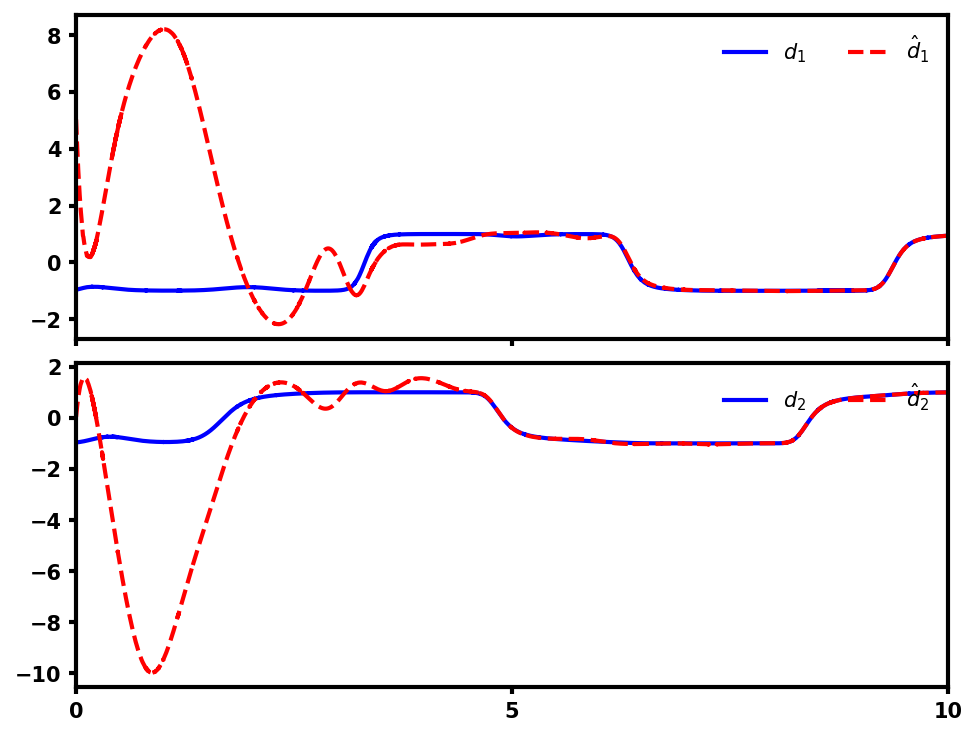

In [234]:
def plot_uios(dist_t, dist_d, dist_d_hat):

    fig, axs = plt.subplots(2, sharex=True, dpi=150, constrained_layout=True)

    ylims = [
        [-5, 5],
        [-5, 5],
    ]

    for i in range(len(axs)):

        axs[i].plot(dist_t, dist_d[:, i], 'b', label=f'$d_{i+1}$', linewidth=2)
        axs[i].plot(dist_t, dist_d_hat[:, i], 'r--', label=f'$\hat{{d}}_{i+1}$', linewidth=2)
        # axs[i].set_ylim(ylims[i])
        axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(1, 1))
        
        axs[i].set_xticks(np.linspace(0, 20, 5))
        
        # if i == 0:
        #     axs[i].set_yticks([0, 1, 2])
        # elif i == 1:
        #     axs[i].set_yticks([-2, 0, 2, 4])
        #     axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.97, 1))

        for tick in axs[i].get_xticklabels():
            tick.set_fontweight('bold')
        for tick in axs[i].get_yticklabels():
            tick.set_fontweight('bold')
        for spine in axs[i].spines.values():
            spine.set_linewidth(2)  # Change the value as needed
        axs[i].tick_params(axis='both', width=2)  # Adjust width and length
        
    plt.xlim([0, time])

    dir = os.path.join(os.curdir, f'.figures/')
    if not os.path.isdir(dir):
        os.mkdir(dir)

    plt.savefig(f".figures/disturbances.png")
    plt.show()

plot_uios(dist_t, dist_d, dist_d_hat)

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_120396\1854391490.py:2: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(dist_t, dist_d_hat[:, 1] + dist_d_hat[:, 2], 'r--', label=f'$\hat{{d}}_{i+1}$', linewidth=2)


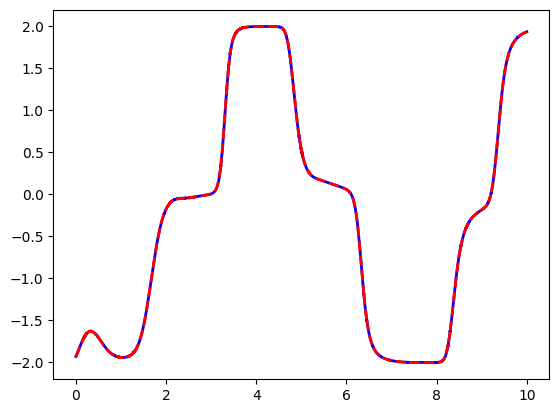

In [ ]:
plt.plot(dist_t, dist_d[:, 1] + dist_d[:, 2], 'b', label=f'$d_{i+1}$', linewidth=2)
plt.plot(dist_t, dist_d_hat[:, 1] + dist_d_hat[:, 2], 'r--', label=f'$\hat{{d}}_{i+1}$', linewidth=2)

<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_120396\938371793.py:16: SyntaxWarning: invalid escape sequence '\h'
  axs[j].plot(x[6+i], x[6+1+i], 'r--', label=f'$\hat{{x}}_{i+1} \\times \hat{{x}}_{i+1+1}$', linewidth=2)
C:\Users\luiza\AppData\Local\Temp\ipykernel_120396\938371793.py:16: SyntaxWarning: invalid escape sequence '\h'
  axs[j].plot(x[6+i], x[6+1+i], 'r--', label=f'$\hat{{x}}_{i+1} \\times \hat{{x}}_{i+1+1}$', linewidth=2)


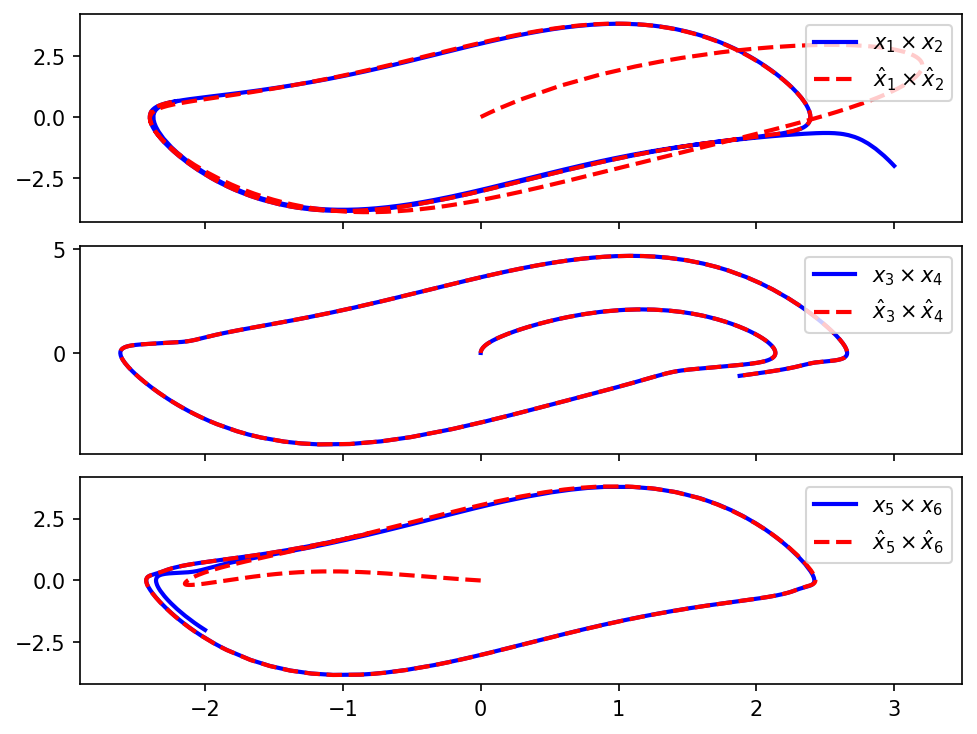

In [ ]:
def plot_graph(x, nx):

    fig, axs = plt.subplots(nx//2, sharex=True, dpi=150, constrained_layout=True)

    ylims = [
        [0, 4],
        [-2, 4],
        [-5, 5],
        [-5, 5]
    ]

    i = 0
    for j in range(len(axs)):

        axs[j].plot(x[i], x[i+1], 'b', label=f'$x_{i+1} \\times x_{i+1+1}$', linewidth=2)
        axs[j].plot(x[6+i], x[6+1+i], 'r--', label=f'$\hat{{x}}_{i+1} \\times \hat{{x}}_{i+1+1}$', linewidth=2)
        # axs[i].set_ylim(ylims[i])
        axs[j].legend(ncols=1, frameon=True, loc='upper right')#, bbox_to_anchor=(1, 1.1))

        # if i == 2:
        #     axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.98, 1.1))
        # elif i == 3:
        #     axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.91, 1.1))
        
        # axs[i].set_xticks(np.linspace(0, 20, 5))

        # for tick in axs[j].get_xticklabels():
        #     tick.set_fontweight('bold')
        # for tick in axs[j].get_yticklabels():
        #     tick.set_fontweight('bold')
        # for spine in axs[j].spines.values():
        #     spine.set_linewidth(2)  # Change the value as needed
        # axs[j].tick_params(axis='both', width=2)  # Adjust width and length

        i += 2
        
    # plt.xlim([0, time])
    
    plt.savefig(f".figures/states.png")
    plt.show()

plot_graph(x, 6)
    